# Demo script for the ProblemSolver class.

This script is intended to help with debugging problems and solvers.

It create a problem-solver pairing (using the directory) and runs multiple macroreplications of the solver on the problem.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "simopt" / "__init__.py").exists():
            return candidate
    return start

repo_root = _find_repo_root(Path.cwd())
repo_root_str = str(repo_root)
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

import hashlib

import numpy as np
import random

# Import the ProblemSolver class and other useful functions
from simopt.experiment_base import (
	ProblemSolver,
	instantiate_problem,
	instantiate_solver,
	post_normalize,	
	Problem,
)

/Users/benjaminrees/miniconda3/envs/simopt/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
# Specify the names of the solver and problem to test.
# Example with random search solver on continuous newsvendor problem:
# solver_abbr_name = "RNDSRCH"
# problem_abbr_name = "CNTNEWS-1"
solver_abbr_name = "ASTROMORF"
problem_abbr_name = "ROSENBROCK-1"

num_macroreps = 2
num_postreps = num_macroreps * 20
num_postreps_init_opt = 200

In [3]:

SCALABLE_PROBLEMS = [
	"FIXEDSAN-1", 
	"NETWORK-1", 
	"ROSENBROCK-1", 
	"SAN-1", 
	"DYNAMNEWS-1", 
	"FACSIZE-2", 
	"FACSIZE-1", 
	"CONTAM-2"
	]
def scale_dimension(problem_name: str, dimension: int, budget: int) -> Problem:
	"""
	Instantiate a problem with a scaled dimension.
	
	All model and problem factors that depend on the dimension are updated
	before instantiation to ensure consistency.
	
	Args:
		problem_name: The abbreviated name of the problem (e.g., "FACSIZE-2")
		dimension: The desired dimension for the problem
		
	Returns:
		A Problem instance configured for the specified dimension
	"""
	if problem_name not in SCALABLE_PROBLEMS or dimension is -1:
		# For non-scalable problems, just instantiate with defaults
		return instantiate_problem(problem_name, {'budget': budget})
	
	# Build the factors for the new dimension
	model_factors = get_scaled_model_factors(problem_name, dimension)
	problem_factors = get_scaled_problem_factors(problem_name, dimension)
	problem_factors['budget'] = budget
	
	# Instantiate the problem with the scaled factors
	problem = instantiate_problem(
		problem_name,
		problem_fixed_factors=problem_factors,
		model_fixed_factors=model_factors
	)
	
	# Set the problem dimension explicitly
	problem.dim = dimension
	
	# Post-initialization updates for factors that can't be validated during construction
	post_init_updates(problem, problem_name, dimension)
	
	return problem


def get_scaled_model_factors(problem_name: str, dimension: int) -> dict:
	"""
	Generate model factors scaled to the specified dimension.
	
	Args:
		problem_name: The abbreviated name of the problem
		dimension: The target dimension
		
	Returns:
		Dictionary of model factors appropriate for the dimension
	"""
	# Create deterministic RNGs based on problem name + dimension so repeated
	# calls produce the same random factors for the same problem/dimension.
	seed = int(hashlib.sha256(f"{problem_name}:{dimension}".encode()).hexdigest(), 16) % (2**32)
	rng_py = random.Random(seed)
	rng_np = np.random.default_rng(seed)

	if problem_name == 'DYNAMNEWS-1':
		return {
			'num_prod': dimension,
			'c_utility': [int(rng_py.uniform(1,5)) + j for j in range(dimension)],
			'init_level': [int(rng_py.uniform(1,5)) for _ in range(dimension)],
			'price': [int(rng_py.uniform(4,6)) for _ in range(dimension)],
			'cost': [int(rng_py.uniform(1,3)) for _ in range(dimension)],
		}
	
	elif problem_name in ('FACSIZE-1', 'FACSIZE-2'):
		# Use diagonal covariance to avoid expensive Cholesky and reduce rejection rate
		# With mean=500 and std=50 (variance=2500), P(X<0) ≈ 0 for each dimension
		# This makes rejection sampling nearly instant
		variance = 2500.0  # std = 50, mean = 500, so P(X<0) is negligible
		cov_matrix = np.eye(dimension) * variance
		return {
			'mean_vec': [500.0] * dimension,
			'cov': cov_matrix.tolist(),
			'capacity': [float(rng_py.randint(100, 900)) for _ in range(dimension)],
			'n_fac': dimension,
		}
	
	elif problem_name == 'SAN-1':
		# Calculate appropriate num_nodes for the number of edges (dimension)
		# For a DAG: we need num_nodes such that we can have 'dimension' edges
		# with a path from node 1 to num_nodes
		num_nodes = compute_num_nodes_for_dag(dimension)
		arcs = build_san_dag(num_nodes, dimension, rng=rng_py)
		return {
			'num_arcs': dimension,
			'num_nodes': num_nodes,
			'arcs': arcs,
			'arc_means': tuple(round(rng_py.uniform(1, 10), 2) for _ in range(dimension)),
		}
	
	elif problem_name == 'FIXEDSAN-1':
		num_nodes = max(2, rng_py.randint(2, max(2, dimension)))
		return {
			'num_arcs': dimension,
			'num_nodes': num_nodes,
			'arc_means': tuple(float(rng_py.randint(1, 10)) for _ in range(dimension)),
		}
	
	elif problem_name == 'ROSENBROCK-1':
		return {
			'x': (2.0,) * dimension,
			'variance': 1.2,
		}
	elif problem_name == 'ZAKHAROV-1':
		return {
			'x': (2.0,) * dimension,
			'variance': 0.1,
		}   
	
	elif problem_name == 'NETWORK-1':
		process_prob_elem = 1.0 / dimension
		mode_transit_time = [round(rng_py.uniform(0.01, 5), 3) for _ in range(dimension)]
		return {
			'process_prob': [process_prob_elem] * dimension,
			'cost_process': [0.1 / (x + 1) for x in range(dimension)],
			'cost_time': [round(rng_py.uniform(0.01, 2), 3) for _ in range(dimension)],
			'mode_transit_time': mode_transit_time,
			'lower_limits_transit_time': [x / 2 for x in mode_transit_time],
			'upper_limits_transit_time': [2 * x for x in mode_transit_time],
			'n_networks': dimension,
		}
	
	elif problem_name == 'CONTAM-2':
		return {
			'stages': dimension,
			'prev_decision': (0.0,) * dimension,
		}
	
	return {}


def get_scaled_problem_factors(problem_name: str, dimension: int) -> dict:
	"""
	Generate problem factors scaled to the specified dimension.
	
	Only includes factors that will pass validation during construction.
	Factors that depend on model state are updated post-initialization.
	
	Args:
		problem_name: The abbreviated name of the problem
		dimension: The target dimension
		
	Returns:
		Dictionary of problem factors appropriate for the dimension
	"""
	if problem_name == 'DYNAMNEWS-1':
		return {
			'initial_solution': (3.0,) * dimension,
		}
	
	elif problem_name in ('FACSIZE-1', 'FACSIZE-2'):
		# NOTE: installation_costs is validated against NUM_FACILITIES constant (=3)
		# So we can't pass it here - it will be updated post-initialization
		return {
			'initial_solution': (100.0,) * dimension,
			'installation_budget': 500.0 * (dimension / 3),  # Scale budget with dimension
		}
	
	elif problem_name in ('SAN-1', 'FIXEDSAN-1'):
		# NOTE: arc_costs is validated against NUM_ARCS constant (=13)
		# So we can't pass it here - it will be updated post-initialization
		# Use 8.0 (higher arc means = longer durations = worse objective)
		# instead of 1.0 which is near the optimal/lower bound
		return {
			'initial_solution': (8.0,) * dimension,
		}
	
	elif problem_name == 'ROSENBROCK-1':
		return {
			'initial_solution': (2.0,) * dimension,
		}
	
	elif problem_name == 'ZAKHAROV-1':
		return {
			'initial_solution': (2.0,) * dimension,
		}
	
	elif problem_name == 'NETWORK-1':
		return {
			'initial_solution': (1.0 / dimension,) * dimension,
		}
	
	elif problem_name == 'CONTAM-2':
		return {
			'initial_solution': (0.0,) * dimension,
		}
	
	return {}


def post_init_updates(problem: Problem, problem_name: str, dimension: int) -> None:
	"""
	Update problem factors after initialization for factors that couldn't be set during construction.
	
	Some factors are validated against hardcoded constants during construction,
	so they need to be updated after the problem is instantiated.
	
	Args:
		problem: The problem instance to update
		problem_name: The abbreviated name of the problem
		dimension: The target dimension
	"""
	if problem_name in ('FACSIZE-1', 'FACSIZE-2'):
		# Update installation_costs after construction to match the new dimension
		problem.factors['installation_costs'] = (1.0,) * dimension
	
	elif problem_name in ('SAN-1', 'FIXEDSAN-1'):
		# Update arc_costs after construction to match the new dimension
		# arc_costs is used in replicate(): np.sum(arc_costs / x)
		problem.factors['arc_costs'] = (1.0,) * dimension


def compute_num_nodes_for_dag(num_edges: int) -> int:
	"""
	Compute an appropriate number of nodes for a DAG with the given number of edges.
	
	For a DAG with n nodes where we need a path from 1 to n:
	- Minimum edges needed: n-1 (a simple path)
	- Maximum edges possible: n*(n-1)/2 (complete DAG)
	
	We want to find the smallest n such that n*(n-1)/2 >= num_edges
	and n-1 <= num_edges (so we have enough edges for connectivity).
	
	Args:
		num_edges: Desired number of edges
		
	Returns:
		Number of nodes to use
	"""
	# We need at least num_edges + 1 nodes in the worst case (simple path),
	# but we want fewer nodes with more edges between them.
	# Solve: n*(n-1)/2 >= num_edges => n^2 - n - 2*num_edges >= 0
	# n >= (1 + sqrt(1 + 8*num_edges)) / 2
	
	import math
	min_nodes = int(math.ceil((1 + math.sqrt(1 + 8 * num_edges)) / 2))
	
	# Ensure we have at least 2 nodes and the path is possible
	min_nodes = max(2, min_nodes)
	
	# Also ensure num_edges >= min_nodes - 1 (need at least a spanning path)
	# If not, we need more nodes
	while min_nodes - 1 > num_edges:
		min_nodes -= 1
	
	return min_nodes


def build_san_dag(num_nodes: int, num_edges: int, rng: random.Random | None = None) -> list[tuple[int, int]]:
	"""
	Build a directed acyclic graph (DAG) suitable for the SAN model.
	
	The SAN model requires:
	1. Directed edges (arcs) from lower-numbered to higher-numbered nodes
	2. A path must exist from node 1 to node num_nodes
	3. Every node must be reachable from node 1 (for backtracking to work)
	
	This function first creates a simple sequential path from 1 to num_nodes
	(1→2→3→...→n), then adds additional random forward edges until reaching num_edges.
	
	Args:
		num_nodes: Number of nodes (numbered 1 to num_nodes)
		num_edges: Desired number of directed edges
		
	Returns:
		List of (source, target) tuples representing directed edges
		
	Raises:
		ValueError: If the requested configuration is impossible
	"""
	min_edges = num_nodes - 1  # Simple path from 1 to num_nodes
	max_edges = num_nodes * (num_nodes - 1) // 2  # Complete DAG
	
	if num_edges < min_edges:
		raise ValueError(
			f"Cannot create DAG with path 1→{num_nodes}: need at least {min_edges} edges, "
			f"but only {num_edges} requested"
		)
	
	if num_edges > max_edges:
		raise ValueError(
			f"Cannot create DAG with {num_edges} edges: maximum possible is {max_edges} "
			f"for {num_nodes} nodes"
		)
	
	edges = set()
	
	# Step 1: Create a guaranteed SEQUENTIAL path from node 1 to node num_nodes
	# This ensures every node has a predecessor reachable from node 1
	# Path: 1 → 2 → 3 → ... → num_nodes
	for i in range(1, num_nodes):
		edges.add((i, i + 1))
	
	# Step 2: Add additional random forward edges until we reach num_edges
	if len(edges) < num_edges:
		if rng is None:
			rng = random.Random()
		# Generate all possible forward edges not yet in the graph
		all_possible_edges = []
		for i in range(1, num_nodes):
			for j in range(i + 1, num_nodes + 1):
				edge = (i, j)
				if edge not in edges:
					all_possible_edges.append(edge)
        
		# Shuffle and add as many as needed
		rng.shuffle(all_possible_edges)
		edges_needed = num_edges - len(edges)
        
		for edge in all_possible_edges[:edges_needed]:
			edges.add(edge)
	
	return list(edges)

def validate_solver_and_problem_names(solver_name: str, problem_name: str) -> None:
	"""Pre-flight validation for clearer errors before heavy work."""
	try:
		_ = instantiate_solver(solver_name=solver_name, fixed_factors={})
	except Exception as e:
		raise ValueError(f"Unknown or invalid solver code '{solver_name}'. Original error: {e}") from e

	try:
		_ = instantiate_problem(problem_name, problem_fixed_factors=None, model_fixed_factors=None)
	except Exception as e:
		raise ValueError(f"Unknown problem code '{problem_name}'. Original error: {e}") from e


def build_connected_graph(num_nodes: int, num_edges: int, rng: random.Random | None = None) -> list[tuple[int, int]]:
	"""
	Build a connected graph with the specified number of nodes and edges.
	
	Starts with a spanning tree to ensure connectivity, then adds random edges
	until the desired number is reached.
	
	Args:
		num_nodes: Number of nodes in the graph
		num_edges: Desired number of edges
		
	Returns:
		List of (node1, node2) tuples representing edges
	"""
	if num_edges < num_nodes - 1:
		raise ValueError(f"Cannot create connected graph: need at least {num_nodes - 1} edges for {num_nodes} nodes")
	
	edges = set()
    
	if rng is None:
		rng = random.Random()

	# Create a spanning tree first to ensure connectivity
	nodes = list(range(num_nodes))
	rng.shuffle(nodes)
	for i in range(1, num_nodes):
		a = nodes[i]
		b = nodes[rng.randint(0, i - 1)]
		edges.add((min(a, b), max(a, b)))
	
	# Add random edges until we reach the desired number
	max_possible_edges = num_nodes * (num_nodes - 1) // 2
	target_edges = min(num_edges, max_possible_edges)
	
	attempts = 0
	max_attempts = target_edges * 10  # Prevent infinite loop
	while len(edges) < target_edges and attempts < max_attempts:
		a = rng.randint(0, num_nodes - 1)
		b = rng.randint(0, num_nodes - 1)
		if a != b:
			edges.add((min(a, b), max(a, b)))
		attempts += 1
	
	return list(edges)

In [4]:
# If the solver runs have already been performed, specify the file name path.
# If no path is specified, a new run will be performed.
file_name_path = None

if file_name_path is None:
    # Import the ProblemSolver class and other useful functions
    # from simopt.experiment_base import ProblemSolver

    # Initialize an instance of the experiment class.
    solver_fixed_factors = {"crn_across_solns": True, "eta_1": 0.1, "eta_2": 0.8, "gamma_1": 2.5, "gamma_2": 1.2, "gamma_3": 0.5, "lambda_min": 5, "ps_sufficient_rduction": 0.1, "subproblem_regularisation": 0.1, 'initial subspace dimension': 50, 'polynomial degree': 4} 
    # solver_fixed_factors = {}
    solver = instantiate_solver(
        solver_name=solver_abbr_name,
        fixed_factors=solver_fixed_factors,
        solver_rename="ASTROMoRF"
    )

    problem = scale_dimension(
        problem_name=problem_abbr_name,
        dimension=100,
        budget=50000,
    )

    myexperiment = ProblemSolver(solver=solver, problem=problem)

    # Run a fixed number of macroreplications of the solver on the problem.
    myexperiment.run(n_macroreps=num_macroreps)
else:
    # following pair of lines (and uncomment the myexperiment.run(...)
    # line above) to read in results from a .pickle file.
    # file_name_path = ""
    from simopt.experiment_base import read_experiment_results

    myexperiment = read_experiment_results(file_name_path)

/Users/benjaminrees/miniconda3/envs/simopt/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/benjaminrees/miniconda3/envs/simopt/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Iteration 3: Adaptive subspace dimension change: 50 -> 48
Iteration 3: Adaptive subspace dimension change: 50 -> 48
Iteration 6: Adaptive subspace dimension change: 48 -> 46
Iteration 6: Adaptive subspace dimension change: 48 -> 46
Iteration 9: Adaptive subspace dimension change: 46 -> 44
Iteration 9: Adaptive subspace dimension change: 46 -> 44
Iteration 12: Adaptive subspace dimension change: 44 -> 42
Iteration 12: Adaptive subspace dimension change: 44 -> 42
Iteration 15: Adaptive subspace dimension change: 42 -> 40
Iteration 15: Adaptive subspace dimension change: 42 -> 40
Iteration 18: Adaptive subspace dimension change: 40 -> 38
Iteration 18: Adaptive subspace dimension change: 40 -> 38
Iteration 21: Adaptive subspace dimension change: 38 -> 36
Iteration 21: Adaptive subspace dimension change: 38 -> 36
Iteration 24: Adaptive subspace dimension change: 36 -> 34
Iteration 24: Adaptive subspace dimension change: 36 -> 34
Iteration 27: Adaptive subspace dimension change: 34 -> 32
Ite

In [5]:
# Run a fixed number of postreplications at all recommended solutions.
myexperiment.post_replicate(n_postreps=num_postreps)

/Users/benjaminrees/miniconda3/envs/simopt/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/benjaminrees/miniconda3/envs/simopt/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [6]:
from pathlib import Path

file_name_pickle = Path('/Users/benjaminrees/Desktop/Journal_Pickles/crn_experiments/ASTROMORF_ON_NETWORK-1_CRN(True)_POSTREPS.pickle')
myexperiment.record_experiment_results(str(file_name_pickle))
myexperiment.log_experiment_results(file_path=str(file_name_pickle.with_suffix('.txt')))

In [7]:
# Find an optimal solution x* for normalization.
from simopt.experiment_base import post_normalize

post_normalize([myexperiment], n_postreps_init_opt=num_postreps_init_opt)

In [8]:
# Log results.
# myexperiment.log_experiment_results()

Plotting results...
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-04-13_12-22-53/plots/SOLVER_SET_ROSENBROCK-1_all_prog_curves_unnorm (1).png')]


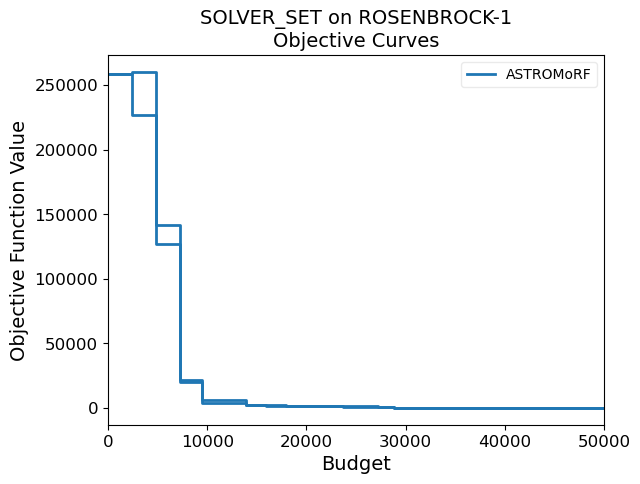

TypeError: only 0-dimensional arrays can be converted to Python scalars

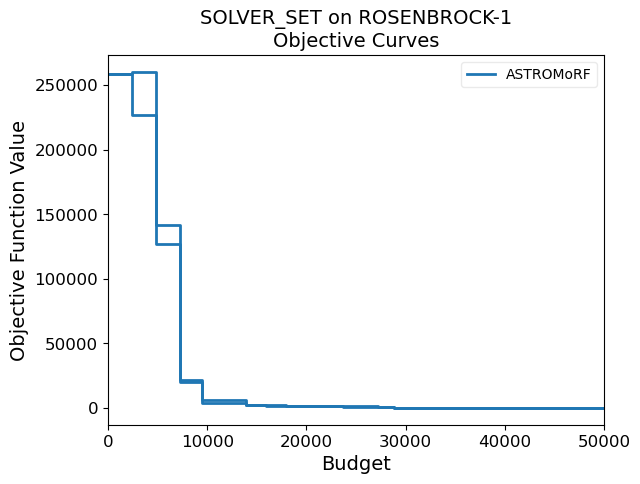

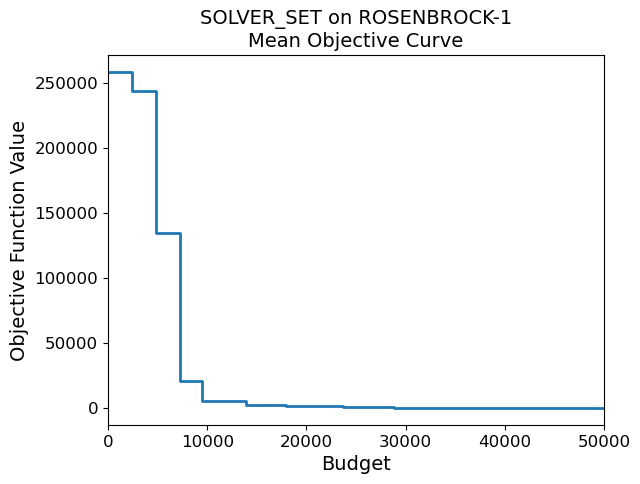

In [10]:
# Produce basic plots.
%matplotlib inline
from IPython.display import Image, display
from simopt.experiment_base import (
    PlotType,
    plot_progress_curves,
    plot_solvability_cdfs,
)

print("Plotting results...")


def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")
    display(Image(filename=str(plot_path[0])))


_print_path(
    plot_progress_curves(
        experiments=[myexperiment], plot_type=PlotType.ALL, normalize=False
    )
)
_print_path(
    plot_progress_curves(
        experiments=[myexperiment], plot_type=PlotType.MEAN, normalize=False
    )
)
_print_path(
    plot_progress_curves(
        experiments=[myexperiment],
        plot_type=PlotType.QUANTILE,
        beta=0.90,
        normalize=False,
    )
)
_print_path(plot_solvability_cdfs(experiments=[myexperiment], solve_tol=0.1))

print("Plotting complete!")